In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data= pd.read_csv('Train (2).csv')

In [4]:
data


,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,No,No,No,No,2.0,0.0,Credit Card,No,No comments,3315000.0
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,11.0,0.0,Cash,Yes,Friendly People,10690875.0
4806,tour_995,NETHERLANDS,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,No,No,No,No,3.0,7.0,Cash,Yes,Good service,2246636.7
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,5.0,0.0,Credit Card,No,Friendly People,1160250.0


### 1.Data Inspection and Exploration

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   str    
 1   country                4809 non-null   str    
 2   age_group              4809 non-null   str    
 3   travel_with            3695 non-null   str    
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   str    
 7   main_activity          4809 non-null   str    
 8   info_source            4809 non-null   str    
 9   tour_arrangement       4809 non-null   str    
 10  package_transport_int  4809 non-null   str    
 11  package_accomodation   4809 non-null   str    
 12  package_food           4809 non-null   str    
 13  package_transport_tz   4809 non-null   str    
 14  package_sightseeing    4809 non-null   str    
 15  package_guided_

In [6]:
data.isnull().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
dtype: int64

We have 4 columns that contain Missing values: 1. Travel_with, 2.Total_female, 3.Total_male, 4.Most_impressing

In [7]:
#Clean the nulls

data['total_female'] = data['total_female'].fillna(0)
data['total_male'] = data['total_male'].fillna(0)

#I've noticed a pattern with the travel_with, its mostly individuals who are alone that left it missing
data['travel_with'] = data['travel_with'].fillna("Alone") 
data['most_impressing'] = data['most_impressing'].fillna("Unknown")

In [8]:
data.isnull().sum()

ID                       0
country                  0
age_group                0
travel_with              0
total_female             0
total_male               0
purpose                  0
main_activity            0
info_source              0
tour_arrangement         0
package_transport_int    0
package_accomodation     0
package_food             0
package_transport_tz     0
package_sightseeing      0
package_guided_tour      0
package_insurance        0
night_mainland           0
night_zanzibar           0
payment_mode             0
first_trip_tz            0
most_impressing          0
total_cost               0
dtype: int64

In [9]:
data

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,Alone,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,No,No,No,No,2.0,0.0,Credit Card,No,No comments,3315000.0
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,11.0,0.0,Cash,Yes,Friendly People,10690875.0
4806,tour_995,NETHERLANDS,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,No,No,No,No,3.0,7.0,Cash,Yes,Good service,2246636.7
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,5.0,0.0,Credit Card,No,Friendly People,1160250.0


### Exploratory analysis

In [10]:
data['total_cost'].describe()

count    4.809000e+03
mean     8.114389e+06
std      1.222490e+07
min      4.900000e+04
25%      8.121750e+05
50%      3.397875e+06
75%      9.945000e+06
max      9.953288e+07
Name: total_cost, dtype: float64

In [11]:
purpose_order = data.groupby('purpose')['total_cost'].mean().sort_values(ascending = False)
purpose_order

purpose
Leisure and Holidays              1.195114e+07
Scientific and Academic           4.031990e+06
Volunteering                      3.950565e+06
Visiting Friends and Relatives    3.190776e+06
Meetings and Conference           2.453004e+06
Business                          1.782438e+06
Other                             1.592155e+06
Name: total_cost, dtype: float64

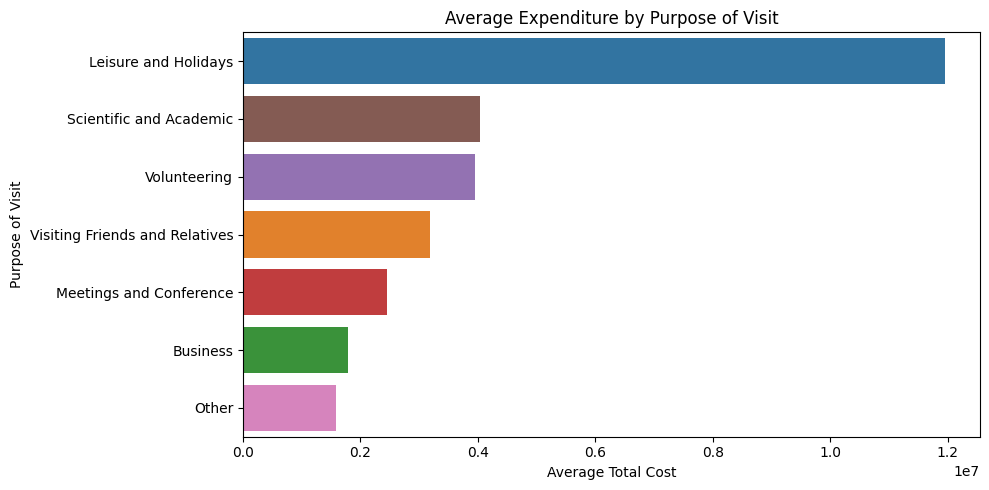

In [12]:
purpose_order = data.groupby('purpose')['total_cost'].mean().sort_values(ascending=False).index

plt.subplots(figsize=(10, 5))
sns.barplot(x='total_cost', y='purpose', data=data, order=purpose_order, errorbar=None, hue = 'purpose')
plt.title('Average Expenditure by Purpose of Visit',)
plt.xlabel('Average Total Cost')
plt.ylabel('Purpose of Visit')
plt.tight_layout()  
plt.savefig('expenditure_by_purpose.png')
plt.show()

In [13]:
sns.set_theme(style="whitegrid")

top_15_countries = data['country'].value_counts().head(15).index
country_df = data[data['country'].isin(top_15_countries)]

C:\Users\user\AppData\Local\Temp\ipykernel_15392\3217698995.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


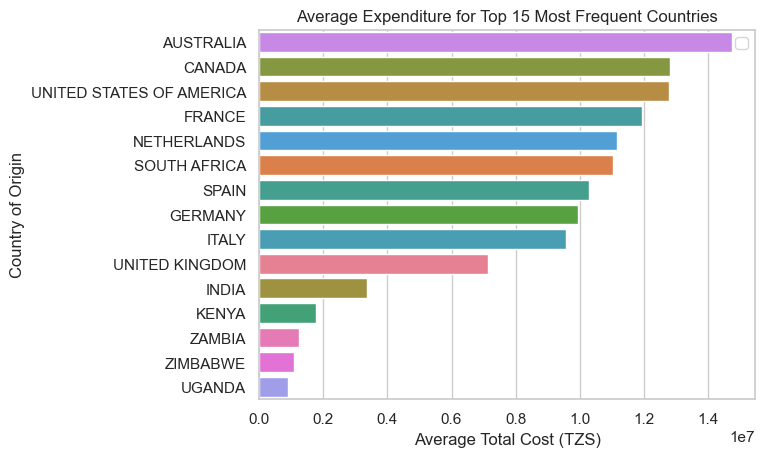

In [14]:
country_order = country_df.groupby('country')['total_cost'].mean().sort_values(ascending=False).index

sns.barplot(
    x='total_cost',
    y='country',
    data=country_df,
    order=country_order,
    errorbar=None,
    hue ='country'
)
plt.title('Average Expenditure for Top 15 Most Frequent Countries')
plt.xlabel('Average Total Cost (TZS)')
plt.ylabel('Country of Origin')
plt.legend()
plt.show()

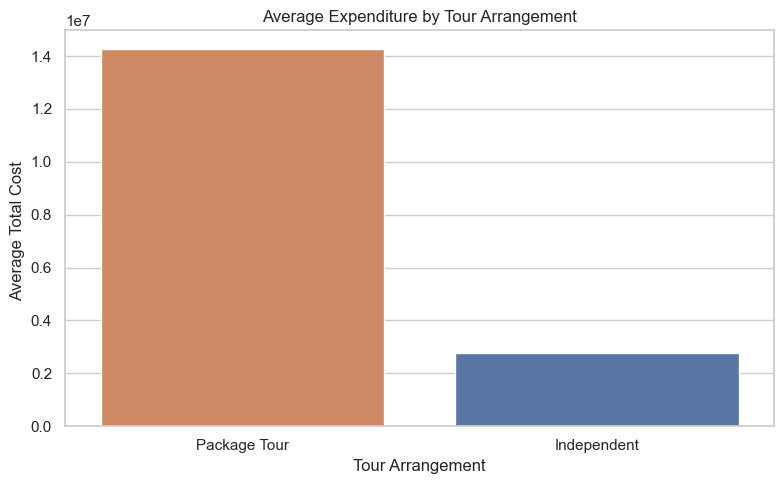

In [15]:
arrangement_order = data.groupby('tour_arrangement')['total_cost'].mean().sort_values(ascending=False).index

plt.subplots(figsize=(8, 5))
sns.barplot(x='tour_arrangement', y='total_cost', data=data, order=arrangement_order, errorbar=None, hue ='tour_arrangement')
plt.title('Average Expenditure by Tour Arrangement')
plt.xlabel('Tour Arrangement')
plt.ylabel('Average Total Cost ')
plt.tight_layout()
plt.savefig('expenditure_by_arrangement.png')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15392\3870031788.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


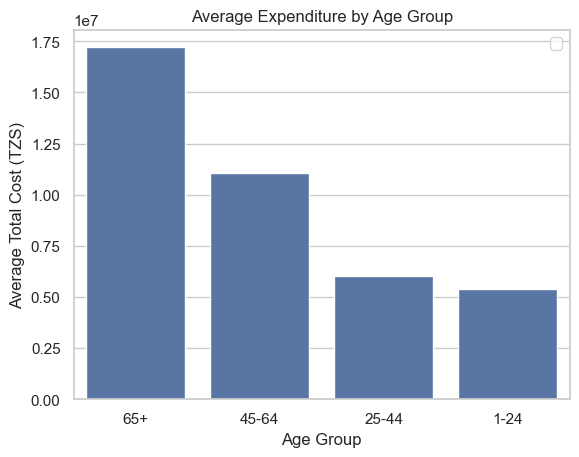

In [16]:
age_order = data.groupby('age_group')['total_cost'].mean().sort_values(ascending=False).index

sns.barplot(
    x='age_group',
    y='total_cost',
    data=data,
    order=age_order,
    errorbar=None,
    
)
plt.title('Average Expenditure by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Cost (TZS)')
plt.legend()
plt.show()

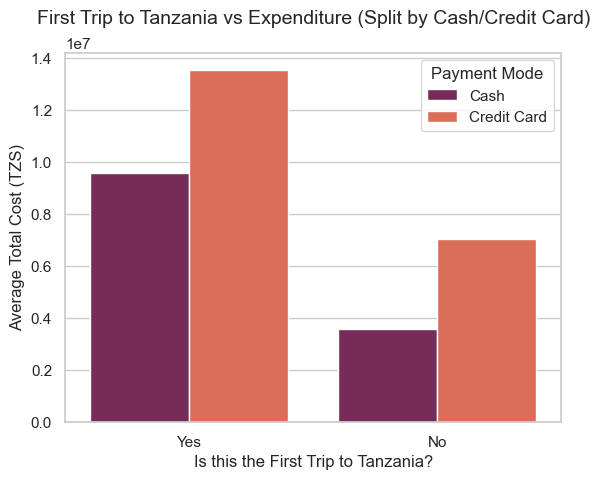

In [17]:
payment_df = data[data['payment_mode'].isin(['Cash', 'Credit Card'])]
trip_order = payment_df.groupby('first_trip_tz')['total_cost'].mean().sort_values(ascending=False).index

sns.barplot(
    x='first_trip_tz',
    y='total_cost',
    hue='payment_mode',  
    data=payment_df,
    order=trip_order,
    errorbar=None,
    palette='rocket'
)
plt.title('First Trip to Tanzania vs Expenditure (Split by Cash/Credit Card)', fontsize=14, pad=10)
plt.xlabel('Is this the First Trip to Tanzania?', fontsize=12)
plt.ylabel('Average Total Cost (TZS)', fontsize=12)
plt.legend(title='Payment Mode')
plt.show()

In [18]:
test = pd.read_csv("Test (1).csv")
test

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing
0,tour_1,AUSTRALIA,45-64,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,Yes,10,3,Cash,Yes,Wildlife
1,tour_100,SOUTH AFRICA,25-44,Friends/Relatives,0.0,4.0,Business,Wildlife tourism,Tanzania Mission Abroad,Package Tour,...,No,No,No,No,No,13,0,Cash,No,"Wonderful Country, Landscape, Nature"
2,tour_1001,GERMANY,25-44,Friends/Relatives,3.0,0.0,Leisure and Holidays,Beach tourism,"Friends, relatives",Independent,...,No,No,No,No,No,7,14,Cash,No,No comments
3,tour_1006,CANADA,24-Jan,Friends/Relatives,2.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,No,0,4,Cash,Yes,Friendly People
4,tour_1009,UNITED KINGDOM,45-64,Friends/Relatives,2.0,2.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Package Tour,...,Yes,Yes,No,No,No,10,0,Cash,Yes,Friendly People
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,tour_988,UNITED STATES OF AMERICA,25-44,NaN,0.0,1.0,Meetings and Conference,Mountain climbing,"Newspaper, magazines,brochures",Independent,...,No,No,No,No,No,1,0,Cash,No,NaN
1597,tour_990,ITALY,45-64,Spouse and Children,3.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Package Tour,...,Yes,Yes,Yes,No,No,10,5,Other,Yes,Wildlife
1598,tour_992,FINLAND,25-44,Alone,0.0,1.0,Meetings and Conference,Mountain climbing,"Friends, relatives",Independent,...,No,No,No,No,No,6,0,Cash,Yes,No comments
1599,tour_996,SOUTH AFRICA,24-Jan,Alone,0.0,1.0,Business,Beach tourism,"Friends, relatives",Independent,...,No,No,No,No,No,4,0,Cash,Yes,Wildlife


In [19]:
test['age_group'] = test['age_group'].replace('24-Jan', '1-24')

In [20]:
#Deal with the nulls
test['travel_with']= test['travel_with'].fillna('Alone')
test['most_impressing']= test['most_impressing'].fillna('Unknown')

test['total_female'] = test['total_female'].fillna(0)
test['total_male'] = test['total_male'].fillna(0)

In [21]:
test['total_people'] = test['total_female'] + test['total_male']
test['total_nights'] = test['night_mainland'] + test['night_zanzibar']

package_cols = ['package_transport_int', 'package_accomodation', 'package_food', 
                'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 'package_insurance']

test['package_count'] = test[package_cols].apply(lambda row: row.str.strip().eq('Yes').sum(), axis=1)

In [22]:
test

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_people,total_nights,package_count
0,tour_1,AUSTRALIA,45-64,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,10,3,Cash,Yes,Wildlife,2.0,13,7
1,tour_100,SOUTH AFRICA,25-44,Friends/Relatives,0.0,4.0,Business,Wildlife tourism,Tanzania Mission Abroad,Package Tour,...,No,No,13,0,Cash,No,"Wonderful Country, Landscape, Nature",4.0,13,2
2,tour_1001,GERMANY,25-44,Friends/Relatives,3.0,0.0,Leisure and Holidays,Beach tourism,"Friends, relatives",Independent,...,No,No,7,14,Cash,No,No comments,3.0,21,0
3,tour_1006,CANADA,1-24,Friends/Relatives,2.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,0,4,Cash,Yes,Friendly People,2.0,4,0
4,tour_1009,UNITED KINGDOM,45-64,Friends/Relatives,2.0,2.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Package Tour,...,No,No,10,0,Cash,Yes,Friendly People,4.0,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,tour_988,UNITED STATES OF AMERICA,25-44,Alone,0.0,1.0,Meetings and Conference,Mountain climbing,"Newspaper, magazines,brochures",Independent,...,No,No,1,0,Cash,No,Unknown,1.0,1,0
1597,tour_990,ITALY,45-64,Spouse and Children,3.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Package Tour,...,No,No,10,5,Other,Yes,Wildlife,4.0,15,4
1598,tour_992,FINLAND,25-44,Alone,0.0,1.0,Meetings and Conference,Mountain climbing,"Friends, relatives",Independent,...,No,No,6,0,Cash,Yes,No comments,1.0,6,0
1599,tour_996,SOUTH AFRICA,1-24,Alone,0.0,1.0,Business,Beach tourism,"Friends, relatives",Independent,...,No,No,4,0,Cash,Yes,Wildlife,1.0,4,0


### Feature engineering

In [23]:
#Total group size
data['total_people '] = data['total_female'] + data['total_male']

In [24]:
#Total duration of stay
data['total_nights'] = data['night_mainland'] + data['night_zanzibar']

In [25]:
#Package inclusivity
package_cols = [
    'package_transport_int', 'package_accomodation', 'package_food', 'package_transport_tz', 'package_sightseeing',
    'package_guided_tour', 'package_insurance'
]

data['package_count'] = data[package_cols].apply(lambda row:row.str.strip().eq("Yes").sum(), axis=1)

In [33]:
country_map = data.groupby('country')['total_cost'].mean()
impressing_map = data.groupby('most_impressing')['total_cost'].mean()

# Map them onto your train data
data['country_encoded'] = data['country'].map(country_map)
data['most_impressing_encoded'] = data['most_impressing'].map(impressing_map)

In [34]:
data

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,total_people,total_nights,package_count,country_encoded,most_impressing_encoded
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,0.0,Cash,No,Friendly People,674602.5,2.0,13.0,0,1.105975e+07,8.230207e+06
1,tour_10,UNITED KINGDOM,25-44,Alone,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5,1.0,21.0,0,7.145183e+06,7.851652e+06
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,31.0,Cash,No,Excellent Experience,3315000.0,1.0,32.0,0,7.145183e+06,7.430729e+06
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,0.0,Cash,Yes,Friendly People,7790250.0,2.0,11.0,5,7.145183e+06,8.230207e+06
4,tour_1004,CHINA,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,4.0,Cash,Yes,No comments,1657500.0,1.0,11.0,0,6.609664e+06,6.627722e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,0.0,Credit Card,No,No comments,3315000.0,1.0,2.0,0,4.437844e+06,6.627722e+06
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,0.0,Cash,Yes,Friendly People,10690875.0,2.0,11.0,7,1.279256e+07,8.230207e+06
4806,tour_995,NETHERLANDS,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,7.0,Cash,Yes,Good service,2246636.7,1.0,10.0,0,1.116265e+07,7.970768e+06
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,0.0,Credit Card,No,Friendly People,1160250.0,2.0,5.0,3,1.104172e+07,8.230207e+06


In [50]:
columns_encode = ['age_group', 'tour_arrangement', 'first_trip_tz', 'purpose', 'payment_mode', 'travel_with']

data_final = pd.get_dummies(data, columns=columns_encode, drop_first=True)

new_columns = [col for col in data_final.columns if any(x in col for x in columns_encode)]

In [51]:
text_columns = data_final.select_dtypes(include=['object']).columns.tolist()
print("Text columns left in X:", text_columns)

C:\Users\user\AppData\Local\Temp\ipykernel_15392\92910583.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = data_final.select_dtypes(include=['object']).columns.tolist()


Text columns left in X: ['ID', 'country', 'main_activity', 'info_source', 'package_transport_int', 'package_accomodation', 'package_food', 'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 'package_insurance', 'most_impressing']


In [52]:
data_final

,ID,country,total_female,total_male,main_activity,info_source,package_transport_int,package_accomodation,package_food,package_transport_tz,...,purpose_Scientific and Academic,purpose_Visiting Friends and Relatives,purpose_Volunteering,payment_mode_Credit Card,payment_mode_Other,payment_mode_Travellers Cheque,travel_with_Children,travel_with_Friends/Relatives,travel_with_Spouse,travel_with_Spouse and Children
0,tour_0,SWIZERLAND,1.0,1.0,Wildlife tourism,"Friends, relatives",No,No,No,No,...,False,False,False,False,False,False,False,True,False,False
1,tour_10,UNITED KINGDOM,1.0,0.0,Cultural tourism,others,No,No,No,No,...,False,False,False,False,False,False,False,False,False,False
2,tour_1000,UNITED KINGDOM,0.0,1.0,Cultural tourism,"Friends, relatives",No,No,No,No,...,False,True,False,False,False,False,False,False,False,False
3,tour_1002,UNITED KINGDOM,1.0,1.0,Wildlife tourism,"Travel, agent, tour operator",No,Yes,Yes,Yes,...,False,False,False,False,False,False,False,False,True,False
4,tour_1004,CHINA,1.0,0.0,Wildlife tourism,"Travel, agent, tour operator",No,No,No,No,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,0.0,1.0,Hunting tourism,"Friends, relatives",No,No,No,No,...,False,False,False,True,False,False,False,False,False,False
4805,tour_994,UNITED STATES OF AMERICA,1.0,1.0,Wildlife tourism,"Travel, agent, tour operator",Yes,Yes,Yes,Yes,...,False,False,False,False,False,False,False,False,True,False
4806,tour_995,NETHERLANDS,1.0,0.0,Wildlife tourism,others,No,No,No,No,...,False,False,False,False,False,False,False,False,False,False
4807,tour_997,SOUTH AFRICA,1.0,1.0,Beach tourism,"Travel, agent, tour operator",Yes,Yes,Yes,No,...,False,False,False,True,False,False,False,True,False,False


In [53]:
cols_to_drop= ['ID', 'country', 'most_impressing', 'info_source', 'main_activity'] + package_cols

X = data_final.drop(columns=['total_cost'] + cols_to_drop)
y = data_final['total_cost']

In [54]:
text_columns_left = X.select_dtypes(include=['object']).columns.tolist()
print("Text columns left in X:", text_columns_left)

Text columns left in X: []


In [55]:
test['country_encoded'] = test['country'].map(country_map)
test['most_impressing_encoded'] = test['most_impressing'].map(impressing_map)

In [56]:
columns_to_encode_test = ['age_group', 'tour_arrangement', 'first_trip_tz', 'purpose', 'payment_mode', 'travel_with']
test_encoded = pd.get_dummies(test, columns=columns_to_encode_test, drop_first=True)

In [41]:
from sklearn.model_selection import train_test_split

In [57]:
X_train_columns = X.columns.tolist()

In [59]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size= 0.2, random_state=42)

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [61]:
y_train_log = np.log1p(y_train)

In [62]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [63]:
model.fit(X_train, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
val_pred_log = model.predict(X_val)

In [65]:
final_val_pred = np.expm1(val_pred_log)

In [67]:
# 3. Calculate metrics
mae = mean_absolute_error(y_val, final_val_pred)
r2 = r2_score(y_val, final_val_pred)

print(f"Internal Validation Mean Absolute Error (MAE): {mae:,.2f} TZS")
print(f"Internal Validation R2 Score: {r2:.4f}")

Internal Validation Mean Absolute Error (MAE): 4,840,669.14 TZS
Internal Validation R2 Score: 0.3105


In [68]:
X_test_final = test_encoded.reindex(columns=X_train_columns, fill_value=0)

In [69]:
log_test_pred = model.predict(X_test_final)

In [71]:
final_val_pred = np.expm1(log_test_pred)

In [72]:
submission_df = pd.DataFrame({
    'ID': test['ID'],
    'total_cost': final_val_pred
})

In [73]:
submission_df.to_csv('submission 1.csv', index=False)
print("Final predictions successfully generated and saved to 'submission 1.csv'!")

Final predictions successfully generated and saved to 'submission 1.csv'!


With an R_score of 30%, lets see if we can increase it abit

In [ ]:
country_map = data.groupby('country')['total_cost'].mean()
impressing_map = data.groupby('most_impressing')['total_cost'].mean()
activity_map = data.groupby('main_activity')['total_cost'].mean() 


data['country_encoded'] = data['country'].map(country_map)
data['most_impressing_encoded'] = data['most_impressing'].map(impressing_map)
data['activity_encoded'] = data['main_activity'].map(activity_map)

In [107]:
data

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,payment_mode,first_trip_tz,most_impressing,total_cost,total_people,total_nights,package_count,country_encoded,most_impressing_encoded,activity_encoded
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,Cash,No,Friendly People,674602.5,2.0,13.0,0,1.105975e+07,8.230207e+06,1.059533e+07
1,tour_10,UNITED KINGDOM,25-44,Alone,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5,1.0,21.0,0,7.145183e+06,7.851652e+06,3.991139e+06
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,Cash,No,Excellent Experience,3315000.0,1.0,32.0,0,7.145183e+06,7.430729e+06,3.991139e+06
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Cash,Yes,Friendly People,7790250.0,2.0,11.0,5,7.145183e+06,8.230207e+06,1.059533e+07
4,tour_1004,CHINA,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,Cash,Yes,No comments,1657500.0,1.0,11.0,0,6.609664e+06,6.627722e+06,1.059533e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,Credit Card,No,No comments,3315000.0,1.0,2.0,0,4.437844e+06,6.627722e+06,1.911327e+06
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Cash,Yes,Friendly People,10690875.0,2.0,11.0,7,1.279256e+07,8.230207e+06,1.059533e+07
4806,tour_995,NETHERLANDS,1-24,Alone,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,Cash,Yes,Good service,2246636.7,1.0,10.0,0,1.116265e+07,7.970768e+06,1.059533e+07
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,Credit Card,No,Friendly People,1160250.0,2.0,5.0,3,1.104172e+07,8.230207e+06,7.524837e+06


In [95]:
columns_encode = ['age_group', 'tour_arrangement', 'first_trip_tz', 'purpose', 'payment_mode', 'travel_with']

In [96]:
data_final = pd.get_dummies(data, columns=columns_encode, drop_first=True)

In [97]:
data_final.columns

Index(['ID', 'country', 'total_female', 'total_male', 'main_activity',
       'info_source', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'most_impressing', 'total_cost', 'total_people ',
       'total_nights', 'package_count', 'country_encoded',
       'most_impressing_encoded', 'activity_encoded', 'age_group_25-44',
       'age_group_45-64', 'age_group_65+', 'tour_arrangement_Package Tour',
       'first_trip_tz_Yes', 'purpose_Leisure and Holidays',
       'purpose_Meetings and Conference', 'purpose_Other',
       'purpose_Scientific and Academic',
       'purpose_Visiting Friends and Relatives', 'purpose_Volunteering',
       'payment_mode_Credit Card', 'payment_mode_Other',
       'payment_mode_Travellers Cheque', 'travel_with_Children',
       'travel_with_Friends/Relatives', 'travel_with_Spouse',
       'travel_wit

In [ ]:
test['country_encoded'] = test['country'].map(country_map)
test['most_impressing_encoded'] = test['most_impressing'].map(impressing_map)
test['activity_encoded'] = test['main_activity'].map(activity_map)  # <-- NEW COLUMN

In [99]:
cols_to_drop = [
    'ID', 'country', 'most_impressing', 'info_source', 'main_activity',
    'package_transport_int', 'package_accomodation', 'package_food', 
    'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 'package_insurance'
]

In [100]:
X = data_final.drop(columns=['total_cost'] + cols_to_drop)
y = data_final['total_cost']

In [102]:
X_test_final = test_encoded.reindex(columns=X.columns.tolist(), fill_value=0)

In [103]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
y_train_log = np.log1p(y_train)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
log_val_predictions = model.predict(X_val)
final_val_predictions = np.expm1(log_val_predictions)

In [106]:
print(f"New Validation MAE: {mean_absolute_error(y_val, final_val_predictions):,.2f} TZS")
print(f"New Validation R2 Score: {r2_score(y_val, final_val_predictions):.4f}")

New Validation MAE: 4,855,464.72 TZS
New Validation R2 Score: 0.3054


In [109]:
log_test_predictions = model.predict(X_test_final)

In [110]:
final_test_predictions = np.expm1(log_test_predictions)

In [111]:
submission_df = pd.DataFrame({
    'ID': test['ID'],
    'total_cost': final_test_predictions
})

In [112]:
submission_df.to_csv('submission 2.csv', index=False)